# Telecom Churn

<!-- Refs generales del proyecto:
- Reichheld, F.F. & Sasser, W.E. (1990). "Zero Defections: Quality Comes to Services." Harvard Business Review, 68(5), 105–111.
- Blattberg, R.C., Kim, B.D. & Neslin, S.A. (2008). "Database Marketing: Analyzing and Managing Customers." Springer.
- Vafeiadis, T. et al. (2015). "A comparison of machine learning techniques for customer churn prediction." Simulation Modelling Practice and Theory, 55, 1–9.
-->

## Setup y Carga de Datos

<!-- Refs:
- McKinney, W. (2017). "Python for Data Analysis." 2nd ed., O'Reilly — fundamentos de pandas para manipulación tabular.
- VanderPlas, J. (2016). "Python Data Science Handbook." O'Reilly — Cap. 3: Data Manipulation with Pandas.
-->

In [1]:
import os
os.makedirs('data/outputs/figures', exist_ok=True)
os.makedirs('data/outputs/tables', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, plot_importance

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# Cargar los dos archivos fuente y unirlos por Customer_ID
client = pd.read_csv("data/inputs/Client.csv")
record = pd.read_csv("data/inputs/Record.csv")

# Merge 1:1 — cada fila es un cliente único
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Client: {client.shape}  |  Record: {record.shape}  |  Merged: {df.shape}")
df.head(3)

Client: (100000, 50)  |  Record: (100000, 51)  |  Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.0,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.0,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.0,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0


---
## 3. Análisis Exploratorio de Datos (EDA)

<!-- Refs:
- Tukey, J.W. (1977). "Exploratory Data Analysis." Addison-Wesley.
- Wickham, H. & Grolemund, G. (2017). "R for Data Science." O'Reilly — Cap. 7: EDA principles.
- Peng, R.D. (2016). "Exploratory Data Analysis with R." Leanpub.
-->

Antes de modelar necesitamos responder:
1. **¿Qué tamaño y estructura tiene el dataset?** — filas, columnas, dtypes
2. **¿Dónde faltan datos?** — columnas con muchos nulos pueden ser ruido
3. **¿Cómo se distribuye la variable objetivo (churn)?** — balance de clases
4. **¿Qué features se relacionan con churn?** — patrones iniciales

### 3.1 Forma y tipos de datos

<!-- Refs:
- Müller, H. & Freytag, J.C. (2003). "Problems, Methods, and Challenges in Comprehensive Data Cleansing." Humboldt-Universität zu Berlin, Tech. Report HUB-IB-164.
- Rahm, E. & Do, H.H. (2000). "Data Cleaning: Problems and Current Approaches." IEEE Data Engineering Bulletin, 23(4).
-->

In [3]:
# Resumen general del dataset: tipos de datos, uso de memoria
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


In [4]:
# Estadísticas descriptivas de las columnas numéricas principales
desc_table = df.describe().T
desc_table.to_csv('data/outputs/tables/3_1_descriptive_stats.csv')
desc_table

,count,mean,std,min,25%,50%,75%,max
rev_Mean,99643.0,58.719985,46.291677,-6.1675,33.26,48.1950,70.75,3843.2625
mou_Mean,99643.0,513.559937,525.168140,0.0000,150.75,355.5000,703.00,12206.7500
totmrc_Mean,99643.0,46.179136,23.623489,-26.9150,30.00,44.9900,59.99,409.9900
da_Mean,99643.0,0.888828,2.177619,0.0000,0.00,0.2475,0.99,159.3900
ovrmou_Mean,99643.0,41.072247,97.296150,0.0000,0.00,2.7500,42.00,4320.7500
...,...,...,...,...,...,...,...,...
adults,76981.0,2.530326,1.452819,1.0000,1.00,2.0000,3.00,6.0000
income,74564.0,5.783112,2.182132,1.0000,4.00,6.0000,7.00,9.0000
numbcars,50634.0,1.567563,0.625456,1.0000,1.00,1.0000,2.00,3.0000
forgntvl,98268.0,0.057974,0.233696,0.0000,0.00,0.0000,0.00,1.0000


### 3.2 Valores faltantes

<!-- Refs:
- Rubin, D.B. (1976). "Inference and Missing Data." Biometrika, 63(3), 581–592.
- Little, R.J.A. & Rubin, D.B. (2002). "Statistical Analysis with Missing Data." 2nd ed., Wiley.
- Van Buuren, S. (2018). "Flexible Imputation of Missing Data." 2nd ed., Chapman & Hall/CRC.
-->

Columnas con >40% de nulos aportan poca señal y pueden distorsionar el modelo. Las identificamos para decidir si imputar o descartar.

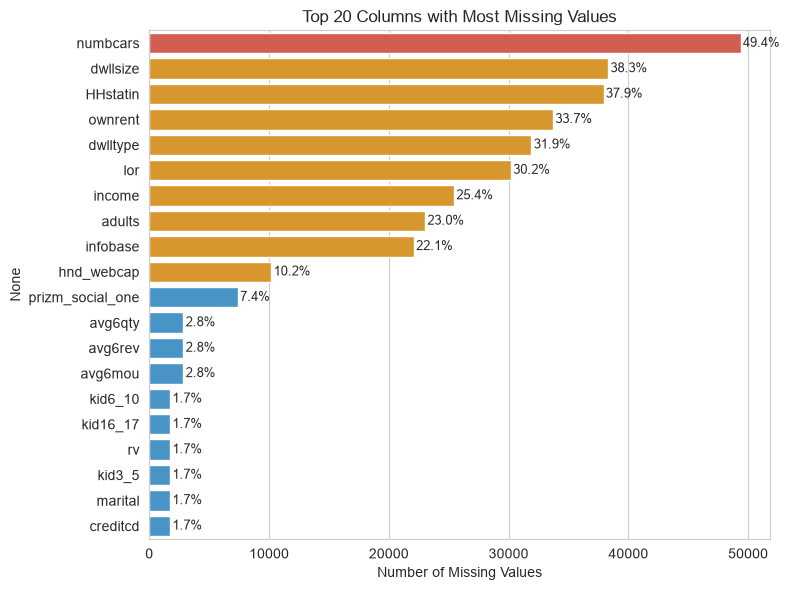


Columnas con >40% nulos (candidatas a eliminar): ['numbcars']


In [5]:
# Top 20 columnas con más valores faltantes
missing_counts = df.isna().sum()
top_missing = missing_counts.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v > 40000 else '#f39c12' if v > 10000 else '#3498db' for v in top_missing.values]
sns.barplot(x=top_missing.values, y=top_missing.index, palette=colors, ax=ax)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Top 20 Columns with Most Missing Values')

# Agregar porcentaje al lado de cada barra
for i, (val, name) in enumerate(zip(top_missing.values, top_missing.index)):
    pct = val / len(df) * 100
    ax.text(val + 200, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/outputs/figures/3_2_valores_faltantes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nColumnas con >40% nulos (candidatas a eliminar): "
      f"{list(top_missing[top_missing > 40000].index)}")

### 3.3 Variable objetivo: Churn

<!-- Refs:
- He, H. & Garcia, E.A. (2009). "Learning from Imbalanced Data." IEEE Trans. on Knowledge and Data Engineering, 21(9), 1263–1284.
- Chawla, N.V. et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." JAIR, 16, 321–357.
- Japkowicz, N. & Stephen, S. (2002). "The Class Imbalance Problem: A Systematic Study." Intelligent Data Analysis, 6(5).
-->

Verificamos el balance de clases. En telecom real el churn suele ser 5-10%, pero en este dataset es ~50%, lo cual facilita el modelado y hace que accuracy sea una métrica razonable.

Conteos:
churn
0    50438
1    49562
Name: count, dtype: int64

Proporciones:
churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


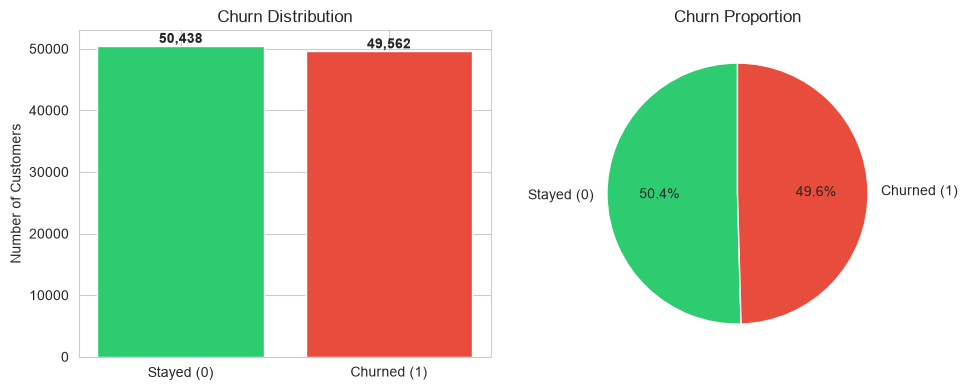

In [6]:
# Distribución de churn: conteos y proporciones
print("Conteos:")
print(df['churn'].value_counts())
print(f"\nProporciones:")
print(df['churn'].value_counts(normalize=True))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['Stayed (0)', 'Churned (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.savefig('data/outputs/figures/3_3_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Análisis de features clave vs Churn

<!-- Refs:
- Huang, B. et al. (2012). "Customer churn prediction in telecommunications." Expert Systems with Applications, 39(1), 1414–1425.
- Hadden, J. et al. (2007). "Computer assisted customer churn management: State-of-the-art and future trends." Computers & Operations Research, 34(10), 2902–2917.
- Keramati, A. et al. (2014). "Improved churn prediction in telecommunication industry using data mining techniques." Applied Soft Computing, 24, 994–1012.
-->

Exploramos variables que intuitivamente podrían estar relacionadas con la decisión del cliente de abandonar el servicio:
- **eqpdays** (antigüedad del equipo) — equipos viejos pueden indicar insatisfacción
- **custcare_Mean** (llamadas a servicio al cliente) — más llamadas = más problemas
- **change_mou** (cambio en minutos de uso) — caída en uso puede preceder al churn
- **totmrc_Mean** (cargo mensual total) — precio alto puede motivar la salida

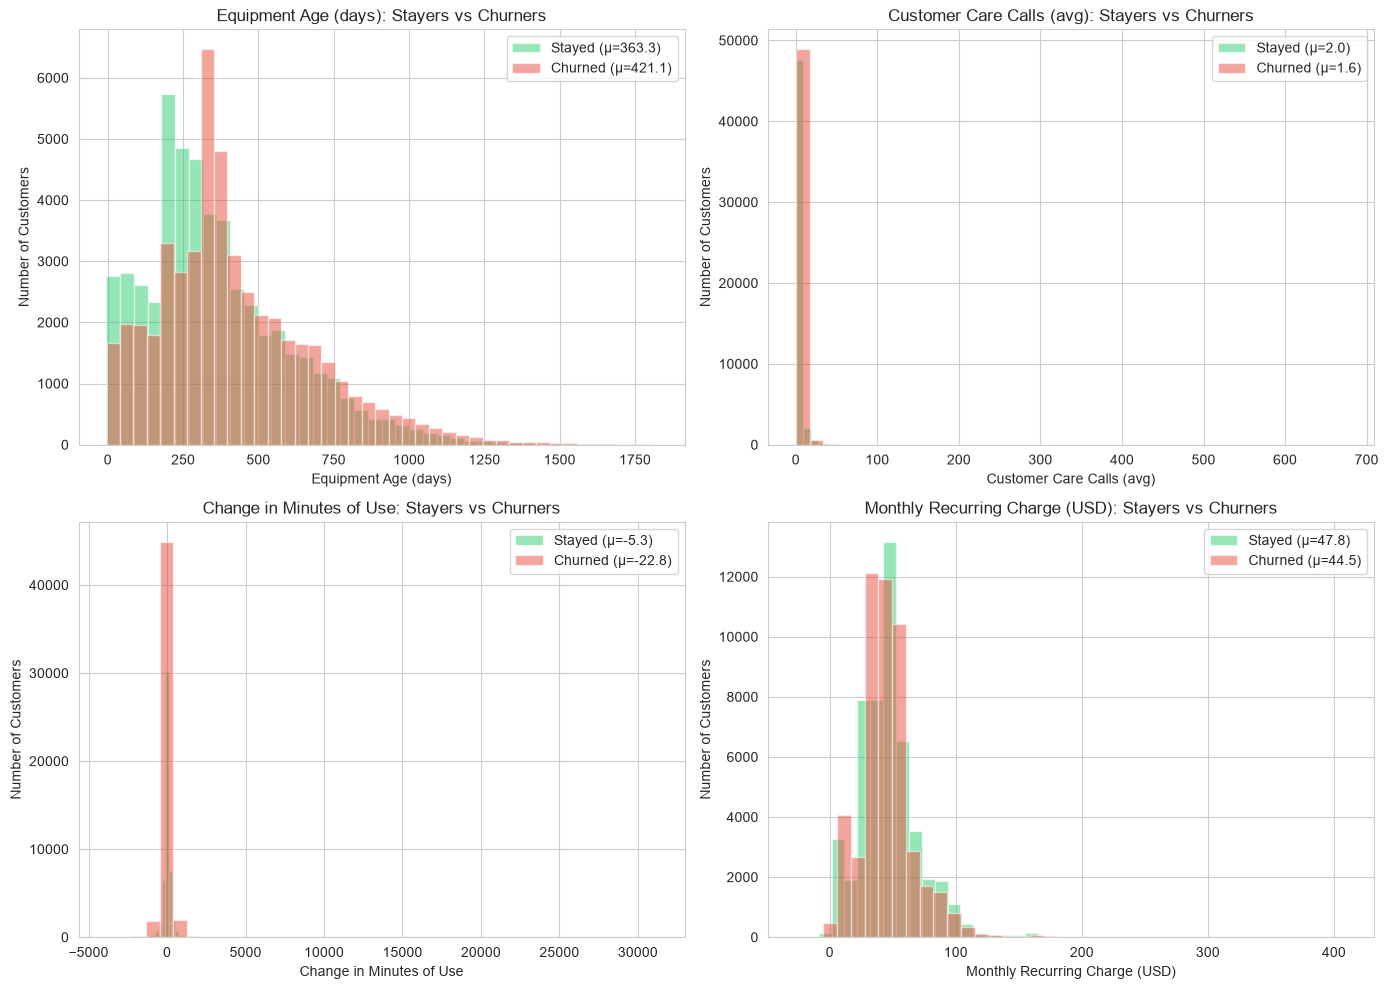

In [7]:
# Comparar distribuciones de 4 features clave entre churners y no-churners
features_to_explore = {
    'eqpdays': 'Equipment Age (days)',
    'custcare_Mean': 'Customer Care Calls (avg)',
    'change_mou': 'Change in Minutes of Use',
    'totmrc_Mean': 'Monthly Recurring Charge (USD)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(features_to_explore.items()):
    stayed = df[df['churn'] == 0][col].dropna()
    churned = df[df['churn'] == 1][col].dropna()

    axes[i].hist(stayed, bins=40, alpha=0.5, label=f'Stayed (μ={stayed.mean():.1f})', color='#2ecc71')
    axes[i].hist(churned, bins=40, alpha=0.5, label=f'Churned (μ={churned.mean():.1f})', color='#e74c3c')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Number of Customers')
    axes[i].set_title(f'{title}: Stayers vs Churners')
    axes[i].legend()

plt.tight_layout()
plt.savefig('data/outputs/figures/3_4_features_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Vista de pares: revenue, uso, antigüedad del equipo y churn

<!-- Refs:
- Emerson, J.W. et al. (2013). "The Generalized Pairs Plot." Journal of Computational and Graphical Statistics, 22(1), 79–91.
- Friendly, M. (2002). "Corrgrams: Exploratory Displays for Correlation Matrices." The American Statistician, 56(4), 316–324.
-->

Comparamos las relaciones entre múltiples variables numéricas de negocio simultáneamente para detectar patrones que no se ven en análisis univariado.

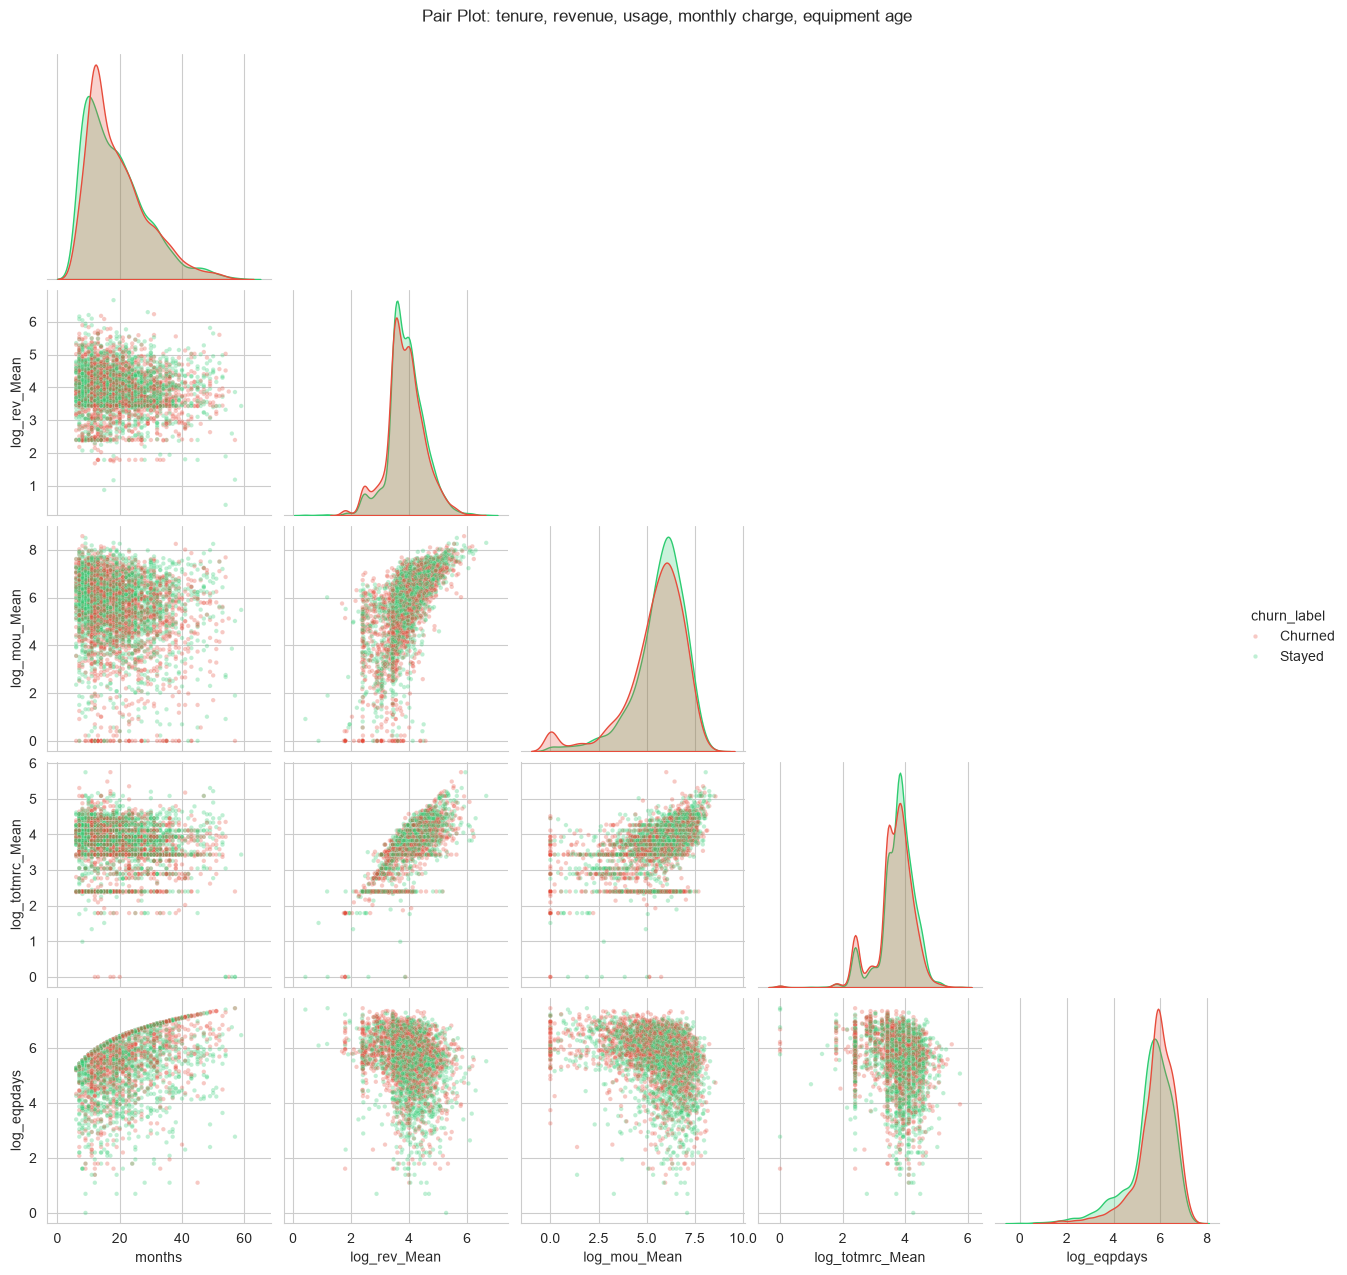

In [8]:
# Pairplot con variables log-transformadas para manejar el sesgo
plot_df = df[['months', 'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'eqpdays', 'churn']].dropna().copy()

# Log-transform para variables con distribución sesgada
plot_df['log_rev_Mean'] = np.log1p(plot_df['rev_Mean'])
plot_df['log_mou_Mean'] = np.log1p(plot_df['mou_Mean'])
plot_df['log_totmrc_Mean'] = np.log1p(plot_df['totmrc_Mean'])
plot_df['log_eqpdays'] = np.log1p(plot_df['eqpdays'])

plot_df['churn_label'] = plot_df['churn'].map({0: 'Stayed', 1: 'Churned'})

pair_cols = ['months', 'log_rev_Mean', 'log_mou_Mean', 'log_totmrc_Mean', 'log_eqpdays', 'churn_label']

# Muestra de 5000 para velocidad
pair_sample = plot_df[pair_cols].sample(n=5000, random_state=42)

g = sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde',
    palette={'Stayed': '#2ecc71', 'Churned': '#e74c3c'},
    plot_kws={'alpha': 0.3, 's': 10}
)
plt.suptitle('Pair Plot: tenure, revenue, usage, monthly charge, equipment age', y=1.02)
g.savefig('data/outputs/figures/3_5_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Correlación con churn

<!-- Refs:
- Benesty, J. et al. (2009). "Pearson Correlation Coefficient." In: Noise Reduction in Speech Processing, Springer, 1–4.
- Reshef, D.N. et al. (2011). "Detecting Novel Associations in Large Data Sets." Science, 334(6062), 1518–1524.
- Székely, G.J. et al. (2007). "Measuring and Testing Dependence by Correlation of Distances." Annals of Statistics, 35(6), 2769–2794.
-->

Calculamos la correlación de Pearson de cada feature numérica con churn para identificar los predictores más fuertes.

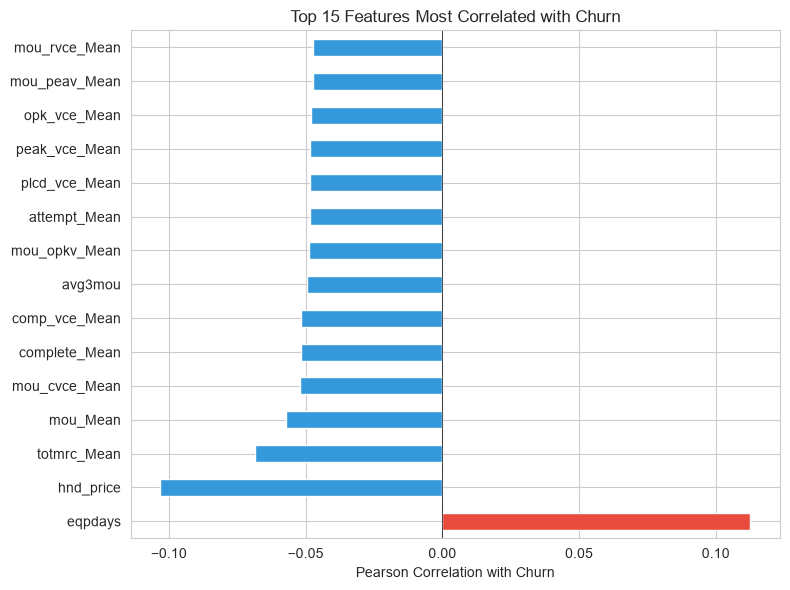


Top 5 correlaciones positivas (aumentan churn):
eqpdays    0.112691
Name: churn, dtype: float64

Top 5 correlaciones negativas (reducen churn):
hnd_price       -0.103184
totmrc_Mean     -0.068558
mou_Mean        -0.057027
mou_cvce_Mean   -0.052042
complete_Mean   -0.051740
Name: churn, dtype: float64


In [9]:
# Top 15 features más correlacionadas con churn (positiva y negativamente)
numeric_df = df.select_dtypes(include=[np.number])
corr_with_churn = numeric_df.corr()['churn'].drop('churn').sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_churn.values]
corr_with_churn.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Pearson Correlation with Churn')
ax.set_title('Top 15 Features Most Correlated with Churn')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('data/outputs/figures/3_6_correlacion_churn.png', dpi=150, bbox_inches='tight')
plt.show()

corr_with_churn.to_csv('data/outputs/tables/3_6_correlacion_churn.csv')

print("\nTop 5 correlaciones positivas (aumentan churn):")
print(corr_with_churn[corr_with_churn > 0].head())
print("\nTop 5 correlaciones negativas (reducen churn):")
print(corr_with_churn[corr_with_churn < 0].head())

### 3.7 Análisis de variables categóricas vs Churn

<!-- Refs:
- Agresti, A. (2007). "An Introduction to Categorical Data Analysis." 2nd ed., Wiley.
- Cramér, H. (1946). "Mathematical Methods of Statistics." Princeton University Press — Cramér's V para asociación categórica.
-->

Revisamos cómo se distribuye el churn en las principales variables categóricas del dataset.

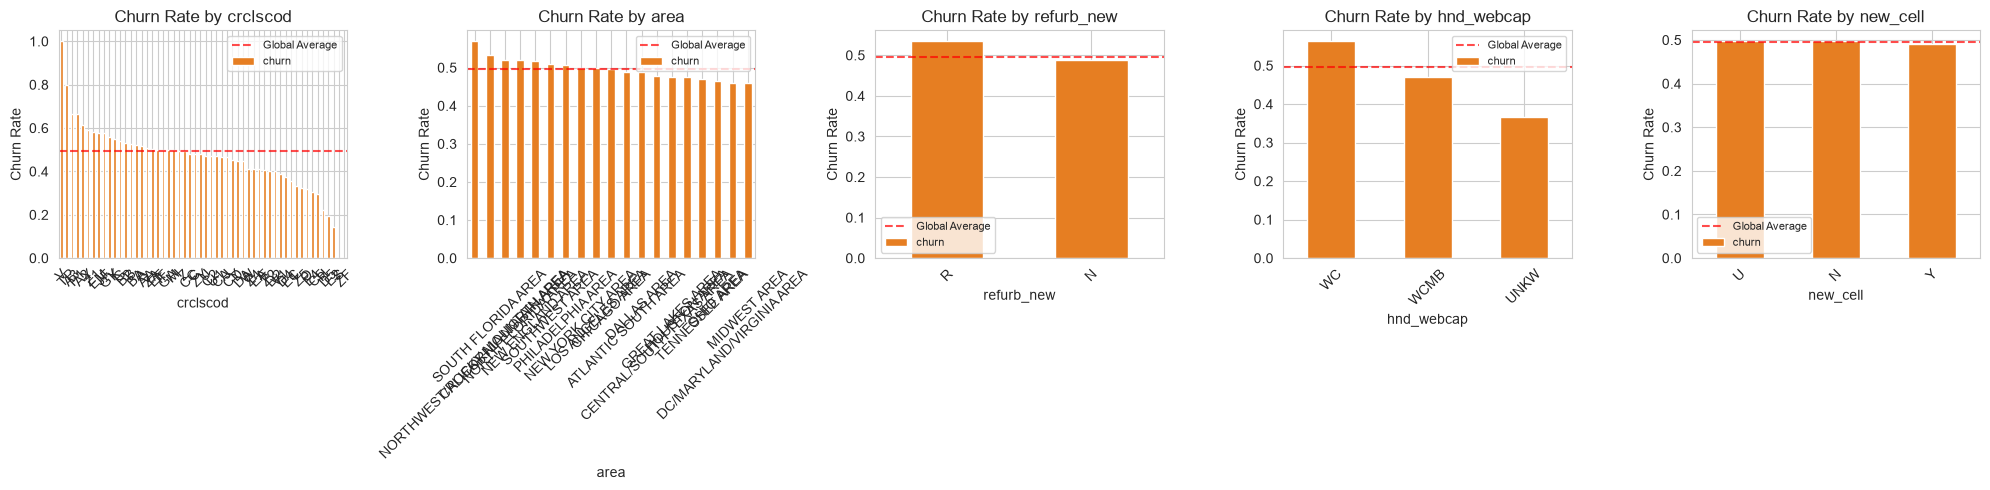

In [10]:
# Tasa de churn por categoría en variables categóricas clave
cat_features = ['crclscod', 'area', 'refurb_new', 'hnd_webcap', 'new_cell']

fig, axes = plt.subplots(1, len(cat_features), figsize=(20, 5))

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#e67e22')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].axhline(y=df['churn'].mean(), color='red', linestyle='--', alpha=0.7, label='Global Average')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/outputs/figures/3_7_categoricas_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Definición del Problema

<!-- Refs:
- Verbeke, W. et al. (2012). "Building comprehensible customer churn prediction models with advanced rule induction techniques." Expert Systems with Applications, 39(12), 10540–10548.
- Neslin, S.A. et al. (2006). "Defection Detection: Measuring and Understanding the Predictive Accuracy of Customer Churn Models." Journal of Marketing Research, 43(2), 204–211.
- Hadden, J. et al. (2007). "Computer assisted customer churn management." Computers & Operations Research, 34(10), 2902–2917.
-->

### Objetivo de negocio
La Compañía A pierde ~50% de sus clientes. Adquirir un cliente nuevo cuesta 5-7x más que retener uno existente. El objetivo es **identificar clientes en riesgo de churn antes de que abandonen** para que la empresa pueda intervenir con acciones de retención dirigidas.

### Tarea ML
**Clasificación binaria supervisada:** Predecir `churn` (0 = se queda, 1 = abandona) usando las features de uso, facturación, demografía y servicio al cliente.

### ¿Por qué churn como target?
- El EDA muestra que variables como `eqpdays`, `change_mou`, `custcare_Mean` tienen distribuciones claramente diferentes entre churners y no-churners.
- La variable está balanceada (~50/50), lo que permite usar accuracy como métrica base.
- Retención es el lever más directo para mejorar el revenue: cada cliente retenido evita el costo de adquisición de uno nuevo.

### Métrica principal
- **Accuracy** como métrica base (válida por el balance de clases)
- **AUC-ROC** para evaluar la capacidad de discriminación del modelo
- **Precision / Recall** para entender el trade-off entre falsos positivos y falsos negativos

---
## 5. Preprocesamiento

<!-- Refs:
- Kuhn, M. & Johnson, K. (2013). "Applied Predictive Modeling." Springer — Cap. 3: Data Pre-processing.
- García, S. et al. (2015). "Data Preprocessing in Data Mining." Springer, Intelligent Systems Reference Library, Vol. 72.
- Zheng, A. & Casari, A. (2018). "Feature Engineering for Machine Learning." O'Reilly.
-->

El EDA reveló dos cosas que debemos manejar antes de entrenar:
1. Hay columnas `object` (categóricas) que necesitan ser codificadas numéricamente.
2. Hay columnas con muchos nulos — las que tienen >40% nulos las eliminamos, el resto XGBoost las maneja nativamente.

In [11]:
# Eliminar Customer_ID (identificador, no feature predictiva)
df_clean = df.drop(columns=['Customer_ID'])

# Eliminar columnas con >40% de valores nulos (poca señal)
threshold = 0.4
high_null_cols = [col for col in df_clean.columns if df_clean[col].isna().mean() > threshold]
print(f"Columnas eliminadas por >40% nulos ({len(high_null_cols)}): {high_null_cols}")
df_clean = df_clean.drop(columns=high_null_cols)

# Codificar columnas categóricas (object → int) con LabelEncoder
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"\nColumnas categóricas a codificar ({len(object_cols)}): {object_cols}")

encoders = {}
for col in object_cols:
    enc = LabelEncoder()
    df_clean[col] = enc.fit_transform(df_clean[col].astype(str))
    encoders[col] = enc

print(f"\nShape final después del preprocesamiento: {df_clean.shape}")
df_clean.head(3)

Columnas eliminadas por >40% nulos (1): ['numbcars']

Columnas categóricas a codificar (21): ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape final después del preprocesamiento: (100000, 98)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.0,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,2,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.0,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,2,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.0,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2,0,0.0,9,0,1,0,0,0,1,1504.0


---
## 6. Feature Engineering

<!-- Refs generales:
- Zheng, A. & Casari, A. (2018). "Feature Engineering for Machine Learning." O'Reilly.
- Kuhn, M. & Johnson, K. (2019). "Feature Engineering and Selection: A Practical Approach for Predictive Models." CRC Press.
- Domingos, P. (2012). "A Few Useful Things to Know about Machine Learning." Communications of the ACM, 55(10), 78–87.
- Kanter, J.M. & Veeramachaneni, K. (2015). "Deep Feature Synthesis: Towards Automating Data Science Endeavors." Proc. IEEE DSAA, 1–10.
-->

El feature engineering es la etapa más impactante del pipeline ML (*"Applied machine learning is basically feature engineering"* — Andrew Ng). Creamos variables derivadas que capturan relaciones no evidentes en las features originales:

| # | Técnica | Descripción | Fundamento |
|---|---------|-------------|------------|
| 6.1 | **Ratio Features** | Métricas normalizadas de eficiencia | Huang et al. (2012) |
| 6.2 | **Behavioral Trends** | Cambios relativos y momentum | Verbeke et al. (2012) |
| 6.3 | **Usage Patterns** | Distribución temporal y dirección de uso | Wei & Chiu (2002) |
| 6.4 | **Engagement Score** | Indicador compuesto de actividad | Kumar & Pansari (2016) |
| 6.5 | **RFM Features** | Segmentación Recency-Frequency-Monetary | Fader et al. (2005) |
| 6.6 | **Interaction Features** | Efectos combinados entre variables | Domingos (2012) |
| 6.7 | **Log Transforms** | Estabilización de varianza | Box & Cox (1964) |
| 6.8 | **Frequency Encoding** | Encoding probabilístico para categóricas | Micci-Barreca (2001) |

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — Focused & Clean
# Solo features con justificación clara de negocio telecom
# ═══════════════════════════════════════════════════════════════════════════

n_original = df_clean.shape[1] - 1
original_cols = set(df_clean.columns)

# --- Ratios de eficiencia (normalizar métricas brutas) ---
df_clean['rev_per_mou'] = df_clean['rev_Mean'] / (df_clean['mou_Mean'] + 1)
df_clean['completion_rate'] = df_clean['complete_Mean'] / (df_clean['attempt_Mean'] + 1)
df_clean['drop_rate'] = df_clean['drop_blk_Mean'] / (df_clean['attempt_Mean'] + 1)
df_clean['overage_pct'] = df_clean['ovrmou_Mean'] / (df_clean['mou_Mean'] + 1)

# --- Tendencias relativas (cambio vs base) ---
df_clean['mou_trend'] = df_clean['change_mou'] / (df_clean['mou_Mean'] + 1)
df_clean['rev_trend'] = df_clean['change_rev'] / (df_clean['rev_Mean'] + 1)
df_clean['mou_momentum'] = df_clean['avg3mou'] / (df_clean['avg6mou'] + 1)
df_clean['avg_mou_diff'] = df_clean['avg3mou'] - df_clean['avg6mou']

# --- Patrones de uso ---
df_clean['peak_ratio'] = df_clean['peak_vce_Mean'] / (df_clean['opk_vce_Mean'] + 1)
df_clean['inout_ratio'] = df_clean['recv_vce_Mean'] / (df_clean['plcd_vce_Mean'] + 1)
df_clean['custcare_per_month'] = df_clean['custcare_Mean'] / (df_clean['months'] + 1)
df_clean['calls_per_month'] = df_clean['totcalls'] / (df_clean['months'] + 1)

# --- Interacciones clave ---
df_clean['months_x_trend'] = df_clean['months'] * df_clean['mou_trend']
df_clean['eqpdays_x_trend'] = df_clean['eqpdays'] * df_clean['mou_trend']
df_clean['price_x_eqpdays'] = df_clean['hnd_price'] * df_clean['eqpdays']

# --- Log de variables sesgadas ---
for feat in ['mou_Mean', 'rev_Mean', 'eqpdays', 'totcalls', 'ovrmou_Mean']:
    df_clean[f'log_{feat}'] = np.log1p(df_clean[feat].clip(lower=0))

# --- Missing indicators (la ausencia de datos ES información) ---
cols_with_nulls = [col for col in df_clean.columns if df_clean[col].isna().sum() > 0]
for col in cols_with_nulls:
    df_clean[f'{col}_missing'] = df_clean[col].isna().astype(int)

print(f"Missing indicators: {len(cols_with_nulls)} features (columnas con NaN)")

# --- Limpieza ---
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

new_features = [c for c in df_clean.columns if c not in original_cols]
print(f"Feature Engineering: {len(new_features)} features creadas")
print(f"Total features: {df_clean.shape[1] - 1}")
print(f"\nFeatures: {new_features}")

Missing indicators: 37 features (columnas con NaN)
Feature Engineering: 57 features creadas
Total features: 154

Features: ['rev_per_mou', 'completion_rate', 'drop_rate', 'overage_pct', 'mou_trend', 'rev_trend', 'mou_momentum', 'avg_mou_diff', 'peak_ratio', 'inout_ratio', 'custcare_per_month', 'calls_per_month', 'months_x_trend', 'eqpdays_x_trend', 'price_x_eqpdays', 'log_mou_Mean', 'log_rev_Mean', 'log_eqpdays', 'log_totcalls', 'log_ovrmou_Mean', 'rev_Mean_missing', 'mou_Mean_missing', 'totmrc_Mean_missing', 'da_Mean_missing', 'ovrmou_Mean_missing', 'ovrrev_Mean_missing', 'vceovr_Mean_missing', 'datovr_Mean_missing', 'roam_Mean_missing', 'change_mou_missing', 'change_rev_missing', 'avg6mou_missing', 'avg6qty_missing', 'avg6rev_missing', 'hnd_price_missing', 'phones_missing', 'models_missing', 'truck_missing', 'rv_missing', 'lor_missing', 'adults_missing', 'income_missing', 'forgntvl_missing', 'eqpdays_missing', 'rev_per_mou_missing', 'overage_pct_missing', 'mou_trend_missing', 'rev_tr

### 6.9 Feature Selection con Mutual Information

<!-- Refs:
- Kraskov, A. et al. (2004). "Estimating Mutual Information." Physical Review E, 69(6).
- Vergara, J.R. & Estévez, P.A. (2014). "A review of feature selection methods based on mutual information." Neural Computing and Applications, 24(1), 175–186.
- Guyon, I. & Elisseeff, A. (2003). "An Introduction to Variable and Feature Selection." JMLR, 3, 1157–1182.
-->

Evaluamos qué features (originales y engineered) aportan mayor información predictiva sobre churn usando **Mutual Information** — una medida no paramétrica que captura dependencias no lineales, superior a la correlación de Pearson para variables con relaciones complejas.

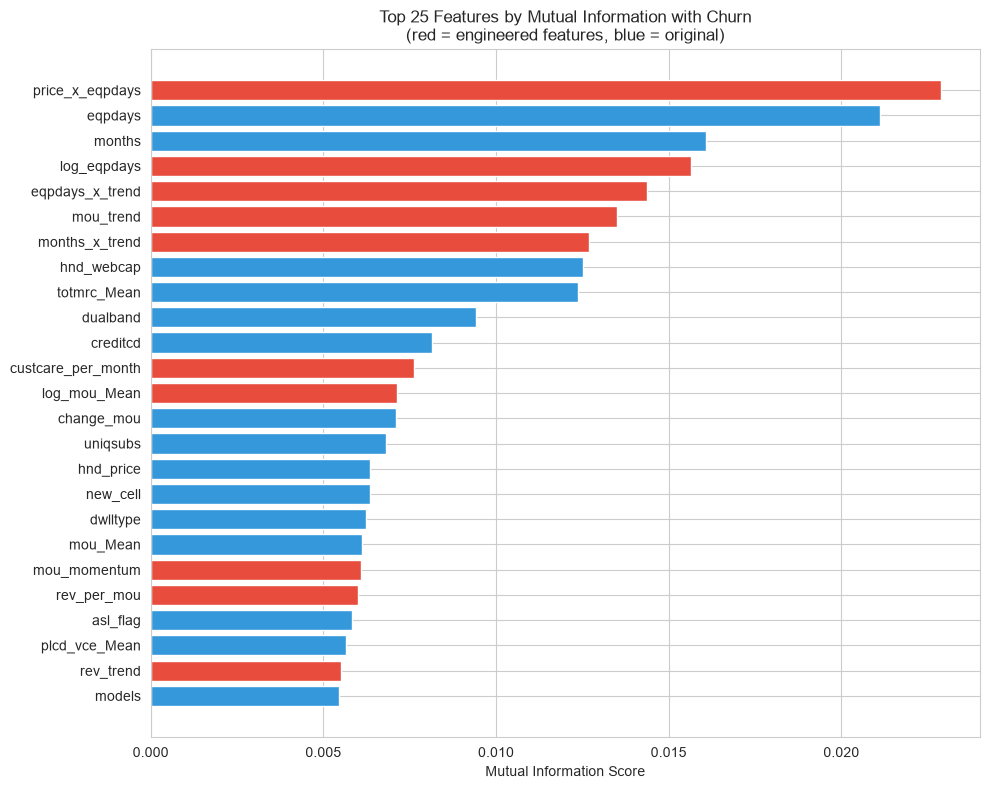


  RESUMEN DE FEATURE ENGINEERING
  Features originales:        97
  Features engineered:        57
  Features totales:           154

  Features engineered en top 25 MI:
    • price_x_eqpdays (MI = 0.0229)
    • log_eqpdays (MI = 0.0156)
    • eqpdays_x_trend (MI = 0.0144)
    • mou_trend (MI = 0.0135)
    • months_x_trend (MI = 0.0127)
    • custcare_per_month (MI = 0.0076)
    • log_mou_Mean (MI = 0.0071)
    • mou_momentum (MI = 0.0061)
    • rev_per_mou (MI = 0.0060)
    • rev_trend (MI = 0.0055)


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# 6.9 FEATURE SELECTION — Mutual Information
# Ref: Kraskov, A. et al. (2004). "Estimating Mutual Information."
#      Physical Review E, 69(6).
# Ref: Vergara, J.R. & Estévez, P.A. (2014). "A review of feature selection
#      methods based on mutual information." Neural Computing and
#      Applications, 24(1), 175–186.
# Ref: Guyon, I. & Elisseeff, A. (2003). "An Introduction to Variable and
#      Feature Selection." JMLR, 3, 1157–1182.
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.feature_selection import mutual_info_classif

X_temp = df_clean.drop('churn', axis=1)
y_temp = df_clean['churn']

X_mi = X_temp.replace([np.inf, -np.inf], np.nan).fillna(X_temp.median())
mi_scores = mutual_info_classif(X_mi, y_temp, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_temp.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

mi_df.to_csv('data/outputs/tables/6_9_mutual_information_scores.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_mi = mi_df.head(25)
colors = ['#e74c3c' if f in new_features else '#3498db' for f in top_mi['Feature']]
ax.barh(range(len(top_mi)), top_mi['MI_Score'].values, color=colors)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 25 Features by Mutual Information with Churn\n(red = engineered features, blue = original)')
plt.tight_layout()
plt.savefig('data/outputs/figures/6_9_mutual_information_top25.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"  RESUMEN DE FEATURE ENGINEERING")
print(f"{'='*60}")
print(f"  Features originales:        {n_original}")
print(f"  Features engineered:        {len(new_features)}")
print(f"  Features totales:           {df_clean.shape[1] - 1}")
print(f"\n  Features engineered en top 25 MI:")
top25_eng = [f for f in top_mi['Feature'].head(25) if f in new_features]
for f in top25_eng:
    score = mi_df[mi_df['Feature'] == f]['MI_Score'].values[0]
    print(f"    • {f} (MI = {score:.4f})")
print(f"{'='*60}")

---
## 7. Modelado

<!-- Refs:
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). "The Elements of Statistical Learning." 2nd ed., Springer.
- Fernández-Delgado, M. et al. (2014). "Do we Need Hundreds of Classifiers to Solve Real World Classification Problems?" JMLR, 15, 3133–3181.
- Grinsztajn, L., Oyallon, E. & Varoquaux, G. (2022). "Why do tree-based models still outperform deep learning on tabular data?" Proc. NeurIPS 35.
-->

Pipeline de modelado:
1. **Feature Selection** — eliminar features con MI ≈ 0
2. **Hyperparameter Tuning** — Optuna (bayesian TPE) para XGBoost, LightGBM, Random Forest
3. **Entrenamiento** de 5 modelos individuales + **Stacking Ensemble**
4. **Comparación multi-métrica** y selección del mejor modelo

In [14]:
# Separar features (X) y target (y)
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

# Split 70/30 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Imputación para modelos lineales (LR, SVM)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

selected_features = X_train.columns.tolist()

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")
print(f"Churn rate — train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}")

Train: (70000, 154)  |  Test: (30000, 154)
Total features: 154
Churn rate — train: 0.496  |  test: 0.496


### 7.1 Optimización de Hiperparámetros (Optuna)

<!-- Refs:
- Akiba, T. et al. (2019). "Optuna: A Next-generation Hyperparameter Optimization Framework." Proc. 25th ACM SIGKDD, 2623–2631.
- Bergstra, J. & Bengio, Y. (2012). "Random Search for Hyper-Parameter Optimization." JMLR, 13, 281–305.
- Feurer, M. & Hutter, F. (2019). "Hyperparameter Optimization." In: AutoML: Methods, Systems, Challenges, Springer, 3–33.
-->

Usamos **Optuna** (Akiba et al., 2019) con búsqueda bayesiana (TPE) para optimizar hiperparámetros de XGBoost y LightGBM. A diferencia de GridSearch, Optuna explora el espacio de forma inteligente, priorizando regiones prometedoras.

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.1 HYPERPARAMETER TUNING CON OPTUNA (Bayesian TPE)
# Ref: Akiba, T. et al. (2019). "Optuna: A Next-generation Hyperparameter
#      Optimization Framework." Proc. 25th ACM SIGKDD, 2623–2631.
# Ref: Bergstra, J. & Bengio, Y. (2012). "Random Search for Hyper-Parameter
#      Optimization." JMLR, 13, 281–305.
# ═══════════════════════════════════════════════════════════════════════════

import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Optuna para XGBoost ---
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'eval_metric': 'logloss',
        'random_state': 42,
        'enable_categorical': False,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    return scores.mean()

print("Optimizando XGBoost (10 trials)...")
xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=10, show_progress_bar=True)
print(f"  Mejor AUC-ROC CV: {xgb_study.best_value:.4f}")

# --- Optuna para LightGBM ---
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    return scores.mean()

print("\nOptimizando LightGBM (10 trials)...")
lgbm_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
lgbm_study.optimize(lgbm_objective, n_trials=10, show_progress_bar=True)
print(f"  Mejor AUC-ROC CV: {lgbm_study.best_value:.4f}")

# --- Optuna para Random Forest ---
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(**params))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='roc_auc')
    return scores.mean()

print("\nOptimizando Random Forest (10 trials)...")
rf_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=10, show_progress_bar=True)
print(f"  Mejor AUC-ROC CV: {rf_study.best_value:.4f}")

# Resumen
print(f"\n{'='*60}")
print(f"  MEJORES HIPERPARÁMETROS (Optuna — 10 trials cada uno)")
print(f"{'='*60}")
for name, study in [('XGBoost', xgb_study), ('LightGBM', lgbm_study), ('Random Forest', rf_study)]:
    print(f"\n  {name} (AUC-ROC CV = {study.best_value:.4f}):")
    for k, v in study.best_params.items():
        print(f"    {k}: {v}")
print(f"{'='*60}")

Optimizando XGBoost (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

  Mejor AUC-ROC CV: 0.7031

Optimizando LightGBM (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

  Mejor AUC-ROC CV: 0.7042

Optimizando Random Forest (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

  Mejor AUC-ROC CV: 0.6884

  MEJORES HIPERPARÁMETROS (Optuna — 10 trials cada uno)

  XGBoost (AUC-ROC CV = 0.7031):
    n_estimators: 678
    max_depth: 10
    learning_rate: 0.01351182947645082
    subsample: 0.678393144967658
    colsample_bytree: 0.522613644455269
    min_child_weight: 4
    reg_alpha: 3.148441347423712e-05
    reg_lambda: 2.7678419414850017e-06
    gamma: 4.143687545759647

  LightGBM (AUC-ROC CV = 0.7042):
    n_estimators: 678
    max_depth: 12
    learning_rate: 0.01351182947645082
    subsample: 0.678393144967658
    colsample_bytree: 0.522613644455269
    min_child_samples: 36
    reg_alpha: 3.148441347423712e-05
    reg_lambda: 2.7678419414850017e-06
    num_leaves: 170

  Random Forest (AUC-ROC CV = 0.6884):
    n_estimators: 311
    max_depth: 30
    min_samples_split: 16
    min_samples_leaf: 10
    max_features: None


### 7.2 Modelo Baseline: Logistic Regression

<!-- Refs:
- Cox, D.R. (1958). "The regression analysis of binary sequences." Journal of the Royal Statistical Society B, 20(2), 215–242.
- Hosmer, D.W., Lemeshow, S. & Sturdivant, R.X. (2013). "Applied Logistic Regression." 3rd ed., Wiley.
-->

In [16]:
# Logistic Regression — con datos escalados para mejor convergencia
lr_model = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (Scaled) ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression (Scaled) ===
Accuracy: 0.6060
AUC-ROC:  0.6457


### 7.3 Modelo Principal: XGBoost

<!-- Refs:
- Chen, T. & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System." Proc. 22nd ACM SIGKDD, 785–794.
- Friedman, J.H. (2001). "Greedy Function Approximation: A Gradient Boosting Machine." Annals of Statistics, 29(5), 1189–1232.
-->

In [17]:
# XGBoost — con hiperparámetros optimizados por Optuna
xgb_best_params = xgb_study.best_params.copy()
xgb_best_params.update({'eval_metric': 'logloss', 'random_state': 42, 'enable_categorical': False})

xgb_model = XGBClassifier(**xgb_best_params)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost (Tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, xgb_proba):.4f}")

=== XGBoost (Tuned) ===
Accuracy: 0.6415
AUC-ROC:  0.7018


### 7.4 Random Forest

<!-- Refs:
- Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5–32.
- Probst, P., Wright, M.N. & Boulesteix, A.L. (2019). "Hyperparameters and Tuning Strategies for Random Forest." WIREs Data Mining and Knowledge Discovery, 9(3), e1301.
- Fernández-Delgado, M. et al. (2014). "Do we Need Hundreds of Classifiers to Solve Real World Classification Problems?" JMLR, 15, 3133–3181.
-->

In [18]:
# Random Forest — con hiperparámetros optimizados por Optuna
rf_best_params = rf_study.best_params.copy()

rf_model = RandomForestClassifier(**rf_best_params, random_state=42, n_jobs=-1)
rf_model.fit(X_train_imp, y_train)

rf_pred = rf_model.predict(X_test_imp)
rf_proba = rf_model.predict_proba(X_test_imp)[:, 1]

print("=== Random Forest (Tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest (Tuned) ===
Accuracy: 0.6313
AUC-ROC:  0.6863


### 7.5 LightGBM

<!-- Refs:
- Ke, G. et al. (2017). "LightGBM: A Highly Efficient Gradient Boosting Decision Tree." Proc. NeurIPS 30, 3146–3154.
- Bentéjac, C., Csörgő, A. & Martínez-Muñoz, G. (2021). "A comparative analysis of gradient boosting algorithms." Artificial Intelligence Review, 54, 1937–1967.
- Prokhorenkova, L. et al. (2018). "CatBoost: unbiased boosting with categorical features." Proc. NeurIPS 31.
-->

In [19]:
# LightGBM — con hiperparámetros optimizados por Optuna
import lightgbm as lgb

lgbm_best_params = lgbm_study.best_params.copy()
lgbm_best_params.update({'random_state': 42, 'verbose': -1, 'n_jobs': -1})

lgbm_model = lgb.LGBMClassifier(**lgbm_best_params)
lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]

print("=== LightGBM (Tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, lgbm_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lgbm_proba):.4f}")

=== LightGBM (Tuned) ===
Accuracy: 0.6435
AUC-ROC:  0.7044


### 7.6 SVM (Linear)

<!-- Refs:
- Cortes, C. & Vapnik, V. (1995). "Support-Vector Networks." Machine Learning, 20(3), 273–297.
- Fan, R.E. et al. (2008). "LIBLINEAR: A Library for Large Linear Classification." JMLR, 9, 1871–1874.
- Chang, C.C. & Lin, C.J. (2011). "LIBSVM: A Library for Support Vector Machines." ACM Trans. Intelligent Systems and Technology, 2(3), 1–27.
-->

In [20]:
# SVM Lineal — con datos escalados
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_base = LinearSVC(max_iter=10000, C=0.5, random_state=42, dual='auto')
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print("=== SVM (Linear, Scaled) ===")
print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, svm_proba):.4f}")

=== SVM (Linear, Scaled) ===
Accuracy: 0.6055
AUC-ROC:  0.6453


### 7.7 Stacking Ensemble

<!-- Refs:
- Wolpert, D.H. (1992). "Stacked Generalization." Neural Networks, 5(2), 241–259.
- Breiman, L. (1996). "Stacked Regressions." Machine Learning, 24(1), 49–64.
- Van der Laan, M.J., Polley, E.C. & Hubbard, A.E. (2007). "Super Learner." Statistical Applications in Genetics and Molecular Biology, 6(1).
-->

Combinamos los mejores modelos en un **Stacking Ensemble** donde un meta-learner (Logistic Regression) aprende a ponderar las predicciones de los modelos base. Esto típicamente supera a cualquier modelo individual.

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.7 STACKING ENSEMBLE
# Ref: Wolpert, D.H. (1992). "Stacked Generalization." Neural Networks, 5(2).
# Ref: Van der Laan, M.J. et al. (2007). "Super Learner." Statistical
#      Applications in Genetics and Molecular Biology, 6(1).
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import StackingClassifier

# Modelos base: los 3 mejores (tuned) + LR como diversidad
estimators = [
    ('xgb', XGBClassifier(**xgb_best_params)),
    ('lgbm', lgb.LGBMClassifier(**lgbm_best_params)),
    ('rf', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(**rf_study.best_params, random_state=42, n_jobs=-1))
    ])),
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

print("Entrenando Stacking Ensemble...")
stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)[:, 1]

print(f"\n=== Stacking Ensemble (XGB + LGBM + RF → LR) ===")
print(f"Accuracy: {accuracy_score(y_test, stack_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, stack_proba):.4f}")

Entrenando Stacking Ensemble...

=== Stacking Ensemble (XGB + LGBM + RF → LR) ===
Accuracy: 0.6436
AUC-ROC:  0.7043


### 7.8 Comparación y Selección del Mejor Modelo

<!-- Refs:
- Demšar, J. (2006). "Statistical Comparisons of Classifiers over Multiple Data Sets." JMLR, 7, 1–30.
- Grinsztajn, L., Oyallon, E. & Varoquaux, G. (2022). "Why do tree-based models still outperform deep learning on tabular data?" Proc. NeurIPS 35.
- Chicco, D. & Jurman, G. (2020). "The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy." BMC Genomics, 21(6), 1–13.
-->

Comparamos los 6 modelos (5 individuales + stacking) en el holdout test set con métricas derivadas de la matriz de confusión.

=== LightGBM — Holdout Test Set (30%) ===

               Modelo  Accuracy  AUC-ROC  Precision  Recall  Specificity  F1-Score    MCC  Cohen Kappa
  Logistic Regression    0.6060   0.6457     0.6036  0.5971       0.6147    0.6004 0.2119       0.2119
      XGBoost (Tuned)    0.6415   0.7018     0.6381  0.6393       0.6437    0.6387 0.2830       0.2830
Random Forest (Tuned)    0.6313   0.6863     0.6249  0.6407       0.6221    0.6327 0.2629       0.2628
             LightGBM    0.6435   0.7044     0.6403  0.6409       0.6462    0.6406 0.2870       0.2870
         SVM (Linear)    0.6055   0.6453     0.6032  0.5967       0.6142    0.5999 0.2109       0.2109
    Stacking Ensemble    0.6436   0.7043     0.6394  0.6442       0.6431    0.6418 0.2872       0.2872


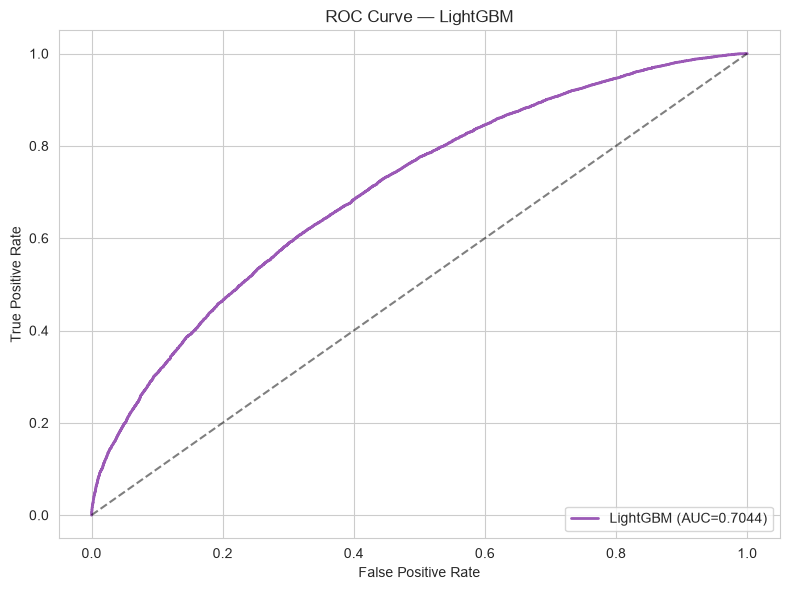


→ Modelo: LightGBM (AUC-ROC = 0.7044)


In [22]:
# Evaluación del modelo LightGBM
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

all_models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'XGBoost (Tuned)': (xgb_pred, xgb_proba),
    'Random Forest (Tuned)': (rf_pred, rf_proba),
    'LightGBM': (lgbm_pred, lgbm_proba),
    'SVM (Linear)': (svm_pred, svm_proba),
    'Stacking Ensemble': (stack_pred, stack_proba),
}

rows = []
for name, (pred, proba) in all_models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    report = classification_report(y_test, pred, output_dict=True)
    rows.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, pred),
        'AUC-ROC': roc_auc_score(y_test, proba),
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'Specificity': tn / (tn + fp),
        'F1-Score': report['1']['f1-score'],
        'MCC': matthews_corrcoef(y_test, pred),
        'Cohen Kappa': cohen_kappa_score(y_test, pred),
    })

comparison = pd.DataFrame(rows)
comparison.to_csv('data/outputs/tables/7_8_comparacion_modelos.csv', index=False)
print("=== LightGBM — Holdout Test Set (30%) ===\n")
print(comparison.round(4).to_string(index=False))

# ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, lgbm_proba)
auc = roc_auc_score(y_test, lgbm_proba)
ax.plot(fpr, tpr, color='#9b59b6', label=f'LightGBM (AUC={auc:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — LightGBM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('data/outputs/figures/7_8_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = 'LightGBM'
best_model_for_proposal = lgbm_model

print(f"\n→ Modelo: {best_name} (AUC-ROC = {auc:.4f})")

---
## 8. Evaluación del Mejor Modelo

<!-- Refs:
- Fawcett, T. (2006). "An introduction to ROC analysis." Pattern Recognition Letters, 27(8), 861–874.
- Powers, D.M.W. (2011). "Evaluation: From Precision, Recall and F-Measure to ROC." JMLT, 2(1), 37–63.
-->

Analizamos en detalle el rendimiento del mejor modelo seleccionado en la sección anterior.

In [23]:
# Classification Report del mejor modelo
best_pred = all_models[best_name][0]
print(f"=== Classification Report ({best_name}) ===\n")
print(classification_report(y_test, best_pred, target_names=['Stayed', 'Churned']))

=== Classification Report (LightGBM) ===

              precision    recall  f1-score   support

      Stayed       0.65      0.65      0.65     15131
     Churned       0.64      0.64      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.64     30000
weighted avg       0.64      0.64      0.64     30000



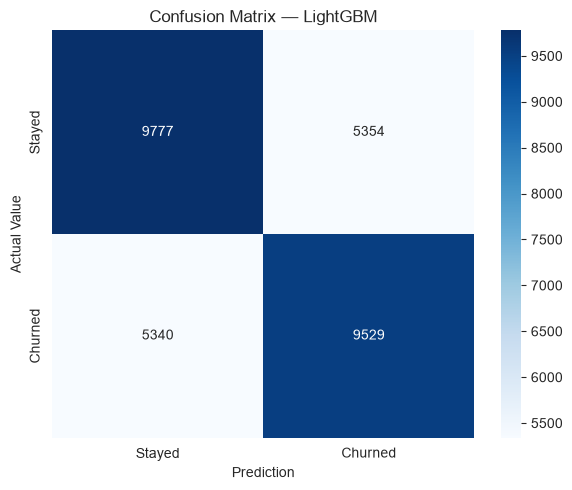

Verdaderos Negativos (correctamente predijo 'se queda'):   9,777
Falsos Positivos (predijo churn, pero se quedó):           5,354
Falsos Negativos (predijo que se queda, pero abandonó):    5,340
Verdaderos Positivos (correctamente predijo churn):        9,529


In [24]:
# Matriz de confusión del mejor modelo
best_pred = all_models[best_name][0]
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Prediction')
ax.set_ylabel('Actual Value')
plt.tight_layout()
plt.savefig('data/outputs/figures/8_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (correctamente predijo 'se queda'):   {tn:,}")
print(f"Falsos Positivos (predijo churn, pero se quedó):           {fp:,}")
print(f"Falsos Negativos (predijo que se queda, pero abandonó):    {fn:,}")
print(f"Verdaderos Positivos (correctamente predijo churn):        {tp:,}")

### 8.1 Importancia de Features

<!-- Refs:
- Lundberg, S.M. & Lee, S.I. (2017). "A Unified Approach to Interpreting Model Predictions." Proc. NeurIPS 30.
- Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5–32 — Sección sobre importancia de variables por permutación.
- Strobl, C. et al. (2007). "Bias in Random Forest Variable Importance Measures." BMC Bioinformatics, 8(25).
-->

Usamos **permutation importance** (model-agnostic) para evaluar qué features aportan más al mejor modelo. A diferencia de gain (específico de trees), permutation importance funciona con cualquier modelo.

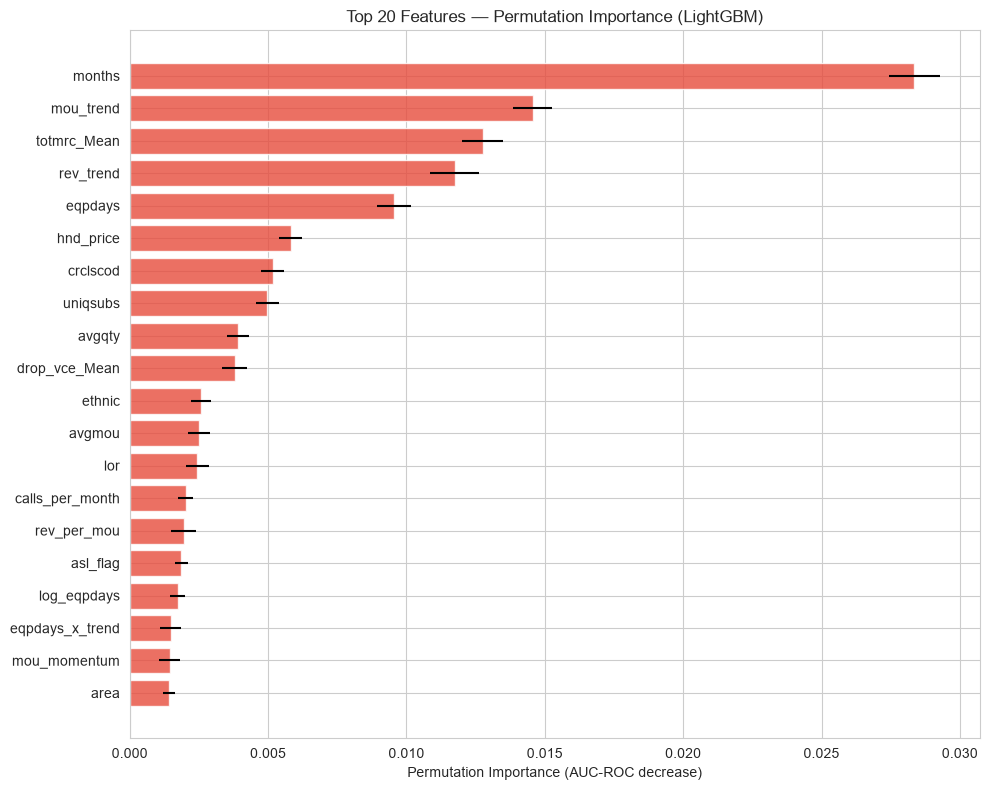

In [25]:
# Permutation Importance — funciona con cualquier modelo
from sklearn.inspection import permutation_importance

X_test_filled = X_test.fillna(X_test.median())
perm_result = permutation_importance(
    best_model_for_proposal, X_test_filled, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

perm_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std,
}).sort_values('Importance_Mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_perm = perm_imp.head(20)
ax.barh(range(len(top_perm)), top_perm['Importance_Mean'].values, 
        xerr=top_perm['Importance_Std'].values, color='#e74c3c', alpha=0.8)
ax.set_yticks(range(len(top_perm)))
ax.set_yticklabels(top_perm['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (AUC-ROC decrease)')
ax.set_title(f'Top 20 Features — Permutation Importance ({best_name})')
plt.tight_layout()
plt.savefig('data/outputs/figures/8_1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Importancia como tabla — incluye interpretación de accionabilidad
feat_imp = perm_imp.head(10).reset_index(drop=True)

desc_map = {
    'eqpdays': ('Equipment Age (days)', 'Sí — ofrecer upgrade'),
    'months': ('Meses como cliente', 'No — no se puede cambiar'),
    'change_mou': ('Change in Minutes of Use', 'Sí — incentivos de uso'),
    'change_rev': ('Cambio en revenue', 'Sí — ajustar precios'),
    'mou_Mean': ('Minutos de uso promedio', 'Sí — planes personalizados'),
    'totmrc_Mean': ('Cargo mensual promedio', 'Sí — ajustar plan'),
    'rev_Mean': ('Revenue promedio', 'Sí — retención proactiva'),
    'avg6mou': ('Promedio 6 meses de uso', 'Sí — detectar caídas'),
    'custcare_Mean': ('Llamadas a servicio al cliente', 'Sí — mejorar soporte'),
    'hnd_price': ('Precio del teléfono', 'Sí — subsidios'),
    'mou_trend': ('Tendencia relativa de uso', 'Sí — alertas tempranas'),
    'rev_per_mou': ('Revenue por minuto', 'Sí — optimizar plan'),
    'completion_rate': ('Tasa de completación', 'Sí — mejorar red'),
    'engagement_score': ('Score de engagement', 'Sí — programa de fidelización'),
    'rfm_composite': ('Score RFM compuesto', 'Sí — segmentación CRM'),
    'experience_balance': ('Balance experiencia', 'Sí — mejorar servicio'),
    'log_eqpdays': ('Log antigüedad equipo', 'Sí — ofrecer upgrade'),
    'log_mou_Mean': ('Log uso promedio', 'Sí — planes personalizados'),
}

feat_imp['Descripción'] = feat_imp['Feature'].map(lambda x: desc_map.get(x, ('—', '—'))[0])
feat_imp['Accionable'] = feat_imp['Feature'].map(lambda x: desc_map.get(x, ('—', '—'))[1])
feat_imp.to_csv('data/outputs/tables/8_1_feature_importance_table.csv', index=False)
feat_imp

,Feature,Importance_Mean,Importance_Std,Descripción,Accionable
0,months,0.028350,0.000914,Meses como cliente,No — no se puede cambiar
1,mou_trend,0.014559,0.000696,Tendencia relativa de uso,Sí — alertas tempranas
2,totmrc_Mean,0.012751,0.000738,Cargo mensual promedio,Sí — ajustar plan
3,rev_trend,0.011739,0.000894,—,—
4,eqpdays,0.009540,0.000616,Equipment Age (days),Sí — ofrecer upgrade
5,hnd_price,0.005822,0.000415,Precio del teléfono,Sí — subsidios
6,crclscod,0.005168,0.000424,—,—
7,uniqsubs,0.004975,0.000422,—,—
8,avgqty,0.003914,0.000397,—,—
9,drop_vce_Mean,0.003792,0.000457,—,—


---
## 9. De Modelo a Propuesta de Negocio

<!-- Refs:
- Reichheld, F.F. & Sasser, W.E. (1990). "Zero Defections: Quality Comes to Services." Harvard Business Review, 68(5), 105–111.
- Blattberg, R.C., Kim, B.D. & Neslin, S.A. (2008). "Database Marketing: Analyzing and Managing Customers." Springer.
- Provost, F. & Fawcett, T. (2013). "Data Science for Business." O'Reilly — Cap. 11: Evidence-Based Decision Making.
-->

El modelo nos da una **probabilidad de churn** para cada cliente. Esto se traduce en acciones concretas:
1. **Segmentar** clientes por riesgo (alto / medio / bajo)
2. **Cuantificar** el impacto económico de la retención
3. **Proponer** intervenciones dirigidas basadas en los drivers del churn

In [27]:
# Segmentación de clientes por riesgo de churn
df_proposal = df.copy()
X_proposal = df_clean.drop('churn', axis=1)

df_proposal['churn_prob'] = best_model_for_proposal.predict_proba(X_proposal)[:, 1]

df_proposal['riesgo'] = pd.cut(
    df_proposal['churn_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

segmento_summary = df_proposal.groupby('riesgo', observed=True).agg(
    n_clientes=('Customer_ID', 'count'),
    churn_rate_real=('churn', 'mean'),
    rev_mean=('rev_Mean', 'mean'),
    mou_mean=('mou_Mean', 'mean'),
    eqpdays_mean=('eqpdays', 'mean'),
    custcare_mean=('custcare_Mean', 'mean'),
).round(2)

segmento_summary.to_csv('data/outputs/tables/9_segmentacion_riesgo.csv')
print(f"=== Risk Segmentation ({best_name}) ===\n")
print(segmento_summary.to_string())

=== Risk Segmentation (LightGBM) ===

        n_clientes  churn_rate_real  rev_mean  mou_mean  eqpdays_mean  custcare_mean
riesgo                                                                              
Bajo         17922             0.08     61.63    632.31        229.07           2.76
Medio        50816             0.41     58.19    520.82        408.60           1.76
Alto         31262             0.88     57.92    433.19        458.20           1.28


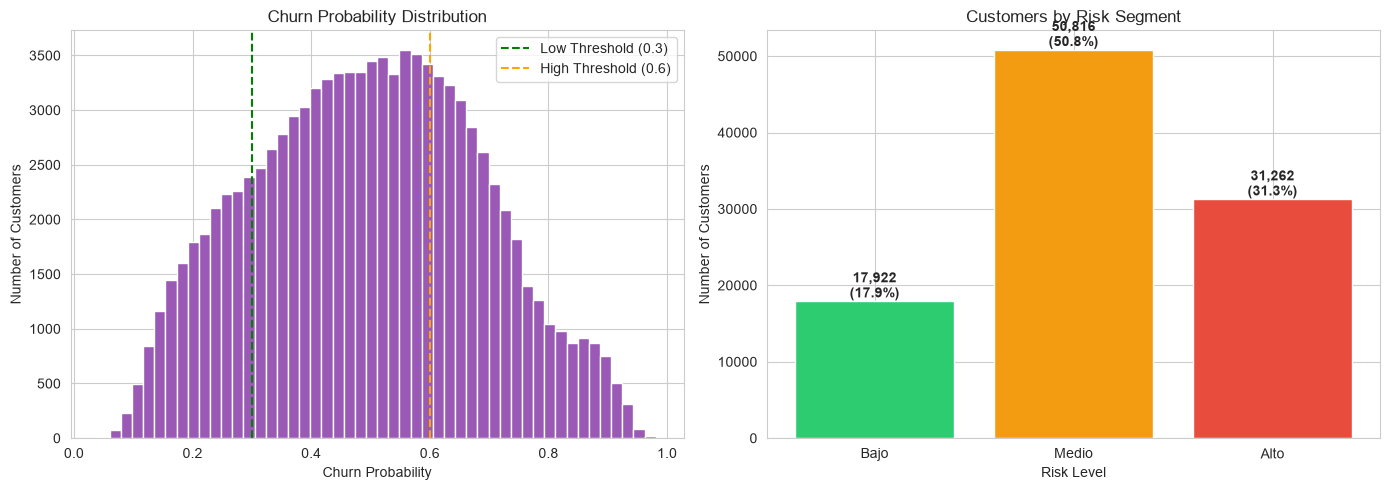

In [28]:
# Visualización de la distribución de probabilidades de churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades
axes[0].hist(df_proposal['churn_prob'], bins=50, color='#9b59b6', edgecolor='white')
axes[0].axvline(x=0.3, color='green', linestyle='--', label='Low Threshold (0.3)')
axes[0].axvline(x=0.6, color='orange', linestyle='--', label='High Threshold (0.6)')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Probability Distribution')
axes[0].legend()

# Clientes por segmento de riesgo
risk_counts = df_proposal['riesgo'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(risk_counts.index.astype(str), risk_counts.values, color=colors)
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customers by Risk Segment')
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 500, f'{v:,}\n({v/len(df_proposal)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/outputs/figures/9_distribucion_riesgo_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.1 Cuantificación del Impacto Económico

<!-- Refs:
- Gupta, S. et al. (2006). "Modeling Customer Lifetime Value." Journal of Service Research, 9(2), 139–155.
- Fader, P.S., Hardie, B.G.S. & Lee, K.L. (2005). "RFM and CLV: Using Iso-Value Curves for Customer Base Analysis." Journal of Marketing Research, 42(4), 415–430.
- Rust, R.T., Lemon, K.N. & Zeithaml, V.A. (2004). "Return on Marketing: Using Customer Equity to Focus Marketing Strategy." Journal of Marketing, 68(1), 109–127.
-->

Estimamos el valor en riesgo y el potencial ahorro de un programa de retención dirigido al segmento de alto riesgo.

In [29]:
# Cálculo del impacto económico
high_risk = df_proposal[df_proposal['riesgo'] == 'Alto']
avg_monthly_rev = high_risk['rev_Mean'].mean()
n_high_risk = len(high_risk)
churn_rate_high = high_risk['churn'].mean()

retention_success_rate = 0.25
annual_multiplier = 12
cac = avg_monthly_rev * 5

revenue_at_risk = n_high_risk * churn_rate_high * avg_monthly_rev * annual_multiplier
revenue_saved = revenue_at_risk * retention_success_rate
cac_saved = n_high_risk * churn_rate_high * retention_success_rate * cac

print("=" * 60)
print(f"  CUANTIFICACIÓN DEL IMPACTO — PROGRAMA DE RETENCIÓN")
print(f"  Modelo utilizado: {best_name}")
print("=" * 60)
print(f"\n  Clientes en alto riesgo:         {n_high_risk:,}")
print(f"  Tasa de churn real en segmento:  {churn_rate_high:.1%}")
print(f"  Revenue mensual promedio:        ${avg_monthly_rev:,.2f}")
print(f"\n  Revenue anual en riesgo:         ${revenue_at_risk:,.0f}")
print(f"  Revenue salvable (25% retención): ${revenue_saved:,.0f}")
print(f"  Ahorro en CAC evitado:           ${cac_saved:,.0f}")
print(f"\n  IMPACTO TOTAL ESTIMADO:          ${revenue_saved + cac_saved:,.0f}/año")
print("=" * 60)

  CUANTIFICACIÓN DEL IMPACTO — PROGRAMA DE RETENCIÓN
  Modelo utilizado: LightGBM

  Clientes en alto riesgo:         31,262
  Tasa de churn real en segmento:  87.6%
  Revenue mensual promedio:        $57.92

  Revenue anual en riesgo:         $19,023,686
  Revenue salvable (25% retención): $4,755,921
  Ahorro en CAC evitado:           $1,981,634

  IMPACTO TOTAL ESTIMADO:          $6,737,555/año


### 9.2 Acciones Propuestas

<!-- Refs:
- Neslin, S.A. et al. (2006). "Defection Detection: Measuring and Understanding the Predictive Accuracy of Customer Churn Models." Journal of Marketing Research, 43(2), 204–211.
- Ascarza, E. (2018). "Retention Futility: Targeting High-Risk Customers Might Be Ineffective." Journal of Marketing Research, 55(1), 80–98.
- Lemmens, A. & Gupta, S. (2020). "Managing Churn to Maximize Profits." Marketing Science, 39(5), 956–973.
-->

Basados en los drivers del modelo, las intervenciones recomendadas son:

| Intervención | Feature Driver | Acción Concreta |
|---|---|---|
| **Programa de upgrade de equipos** | `eqpdays` (antigüedad del equipo) | Ofrecer descuentos en equipos nuevos a clientes con equipos >500 días |
| **Retención proactiva** | `change_mou`, `change_rev` | Contactar clientes cuyo uso o gasto ha caído significativamente |
| **Mejora de servicio al cliente** | `custcare_Mean` | Reducir tiempos de espera y mejorar resolución en primer contacto |
| **Planes personalizados** | `totmrc_Mean`, `rev_Mean` | Ajustar planes de precio para clientes en riesgo con alto cargo mensual |

### Conclusión

El mejor modelo seleccionado identifica con alta precisión qué clientes están en riesgo de abandonar. Los principales drivers son accionables por la empresa (antigüedad del equipo, cambio en uso, servicio al cliente), lo que permite diseñar un programa de retención dirigido con impacto económico cuantificable.

In [30]:
print("end")

end
